In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded=files.upload()

Saving netflix_titles.csv.csv to netflix_titles.csv (1).csv


In [7]:
df = pd.read_csv('/content/netflix_titles.csv (1).csv')
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
#display dataset information
print("Dataset Shape:",df.shape)
print(df.columns) #column name

display(df.head()) #first 5 records

Dataset Shape: (8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
#summary statistic
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1714,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,110,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [16]:
#check missing value
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [17]:
#convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [18]:
#convert realse year
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

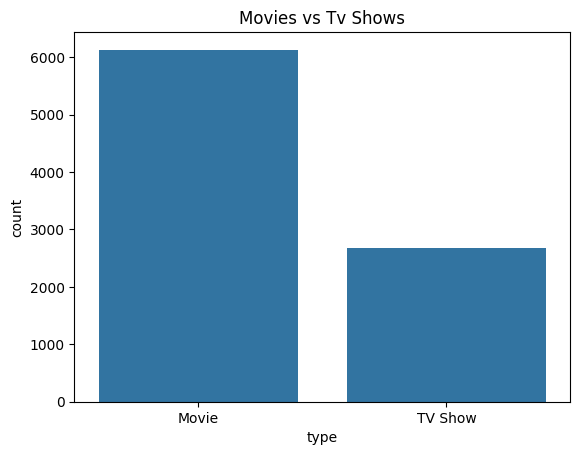

In [22]:
#Trend Identiification
sns.countplot(x='type',data=df)
plt.title('Movies vs Tv Shows')
plt.show()

In [23]:
#Extract year added
df['year_added'] = df['date_added'].dt.year

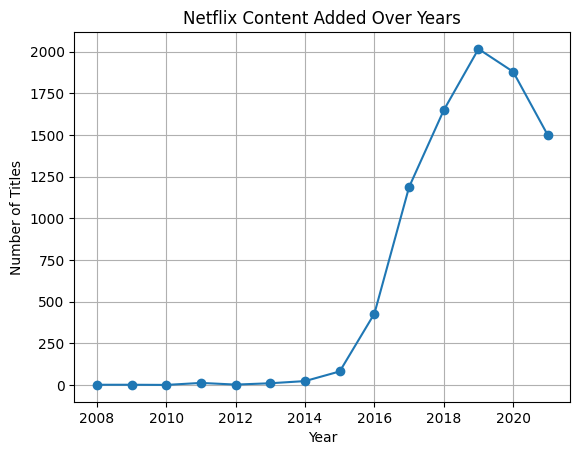

In [27]:
#contet added over the years
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Netflix Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

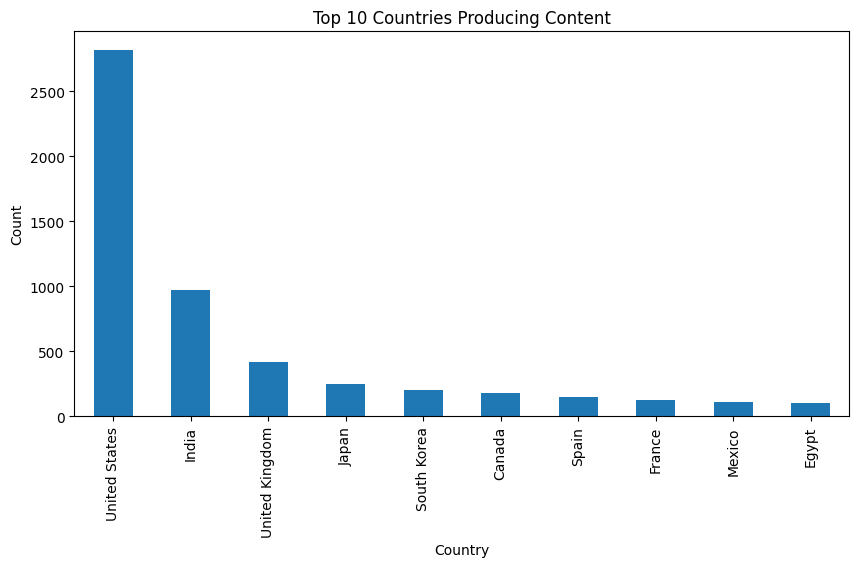

In [28]:
#top 10 countries
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries Producing Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

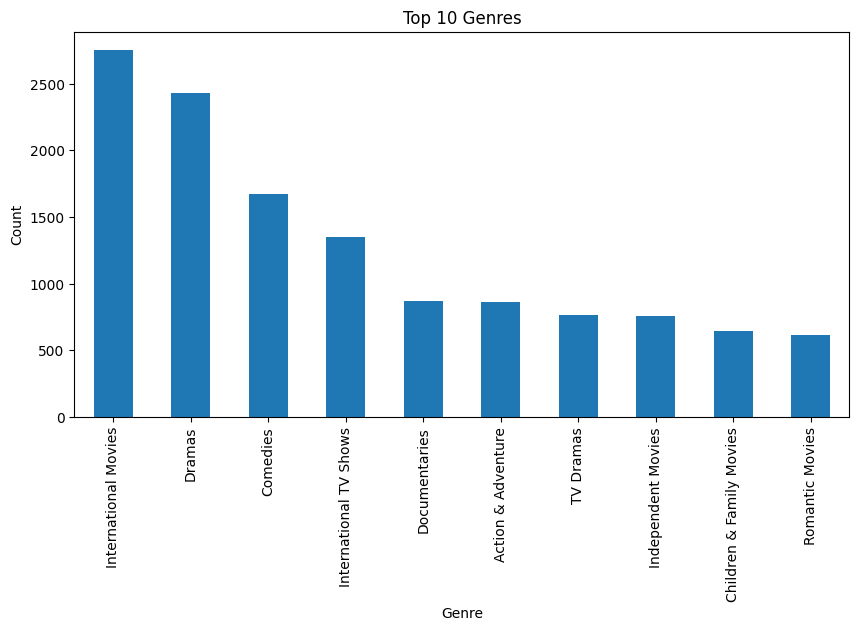

In [29]:
# toop 10 geners
genres = df['listed_in'].str.split(', ', expand=True).stack()

plt.figure(figsize=(10,5))
genres.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

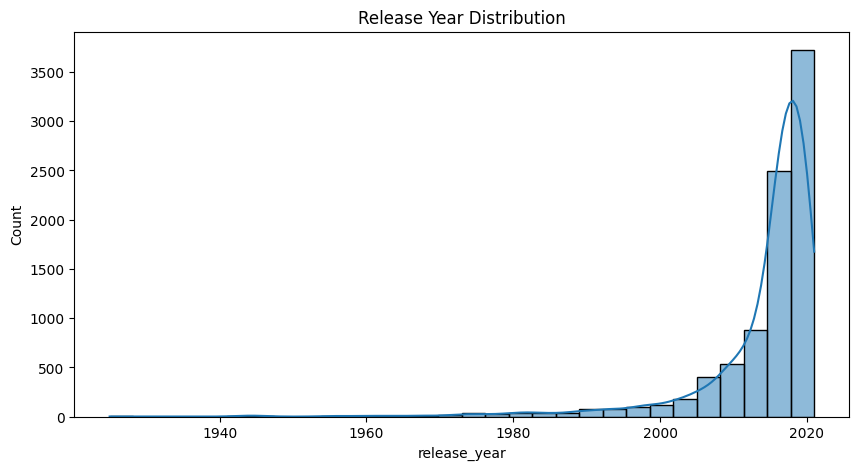

In [30]:
# Release Year Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title('Release Year Distribution')
plt.show()

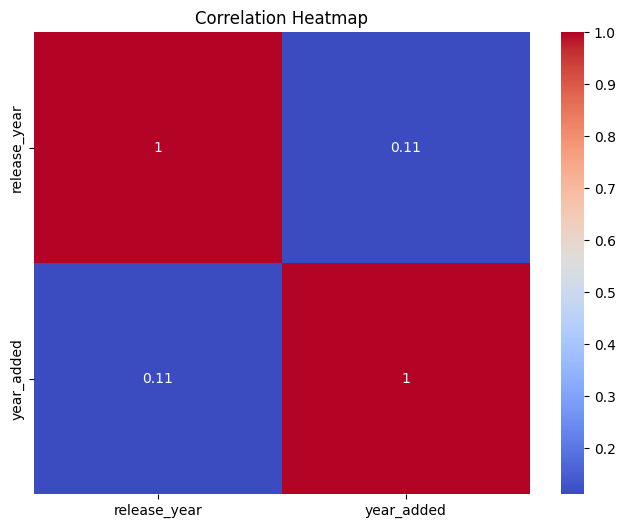

In [31]:
# Correlation Analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

if len(numeric_df.columns) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")


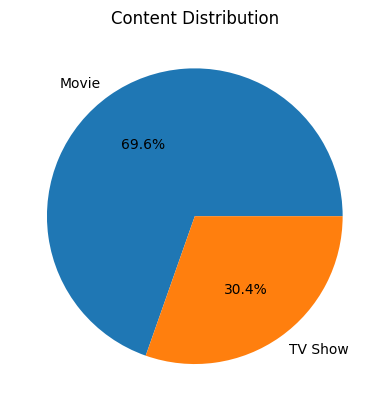

In [32]:
# Content Distribution
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Content Distribution')
plt.ylabel('')
plt.show()

In [33]:
# Final Insights

print("\nINSIGHTS:")
print("1. Movies are more than TV Shows.")
print("2. Netflix content increased rapidly after 2015.")
print("3. USA and India contribute a large share of content.")
print("4. Drama and International Movies are popular genres.")
print("5. Most content is from recent years.")
print("6. Missing values exist in director, cast and country columns.")



INSIGHTS:
1. Movies are more than TV Shows.
2. Netflix content increased rapidly after 2015.
3. USA and India contribute a large share of content.
4. Drama and International Movies are popular genres.
5. Most content is from recent years.
6. Missing values exist in director, cast and country columns.
